# Predicting CAN Bus Intrusion Using Machine Learning

This notebook explores the use of machine learning and Python-based data science libraries to build a model capable of detecting intrusions in in-vehicle CAN (Controller Area Network) communication based on message patterns and timing.

We will take the following approach:

1. **Problem Definition**  
2. **Data**  
3. **Evaluation**  
4. **Features**  
5. **Modelling**  
6. **Experimentation**

---

##  1. Problem Definition

In a single sentence:

> Given CAN bus communication parameters such as timestamp, arbitration ID, and data values, can we predict whether or not a message is part of a cyberattack on the vehicle?


##  2. Data

The dataset was collected from a **KIA SOUL** vehicle via the **OBD-II port** while performing both normal and malicious activities on the CAN bus. It includes the following four states:

1. **DoS Attack** – Repeatedly injecting messages with CAN ID `0x000`
2. **Fuzzy Attack** – Injecting messages with random CAN IDs and data
3. **Impersonation Attack** – Injecting spoofed messages using CAN ID `0x164`
4. **Attack-Free State** – Normal CAN communication

Each record in the dataset contains:

- `Timestamp`: Time in seconds  
- `CAN ID`: Identifier of the message (hexadecimal)  
- `DLC`: Number of data bytes (0 to 8)  
- `DATA[0-7]`: Payload bytes of the CAN message  

The dataset is available for research purposes and was originally used in the **2017 Information Security R&D dataset challenge** in South Korea.

🔗 [IEEE Paper Link](https://ieeexplore.ieee.org/document/8476919)

---

## 3. Evaluation

Our goal is to build a machine learning model that can detect CAN bus intrusions in real-time.  

If the model achieves a detection **accuracy of 90% or higher**, especially in distinguishing between attack and normal states, we will consider the solution effective for practical use.


## 4. Features

This section describes the key features (columns) in the CAN bus dataset. These attributes are derived from in-vehicle communication logs recorded during normal and attack scenarios.

###  Data Dictionary

| Feature       | Description |
|---------------|-------------|
| `Timestamp`   | Time when the CAN message was recorded (in seconds). Useful for computing message frequency, time intervals, or offset ratio. |
| `CAN ID`      | Arbitration ID of the CAN message, represented in hexadecimal (e.g., `0x164`). Can be used to distinguish between different Electronic Control Units (ECUs). |
| `DLC`         | Data Length Code – number of bytes in the message payload (0 to 8). |
| `DATA[0-7]`   | The payload bytes (up to 8) of the CAN message. These bytes may contain status, sensor readings, or control commands. |
| `Label`       | Indicates whether the message is part of an attack or not (only labeled in DoS). In some attack types (like fuzzy or impersonation), the attack window is known (e.g., after 250s), but individual message labels are not provided. |

---

###  Note:
- In DoS attacks, all messages with `CAN ID = 0x000` are considered **abnormal**.
- In fuzzy and impersonation attacks, there are no explicit per-row labels; however, we can infer attacks based on **time windows**.
- Timing-related features like **offset ratio** and **response delay** can be engineered for advanced detection.

---

To improve detection performance, we'll also create derived features such as:
- Message frequency per ID
- Time delta between identical IDs
- Bit-level entropy or data variation
- Offset timing between request and response frames


In [ ]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [ ]:
import re
import pandas as pd

# Prepare to store a sample of lines
sample_size = 100000
data = []

# Regex pattern for the lines
pattern = re.compile(
    r"Timestamp:\s+([0-9.]+)\s+ID:\s+([0-9A-Fa-f]+)\s+\d+\s+DLC:\s+(\d+)\s+((?:[0-9A-Fa-f]{2}\s+){1,8})"
)

with open("data/Attack_free_dataset.txt") as f:
    for i, line in enumerate(f):
        if i >= sample_size:
            break

        match = pattern.search(line)
        if match:
            timestamp = float(match.group(1))
            can_id = int(match.group(2), 16)
            dlc = int(match.group(3))
            data_bytes = [int(b, 16) for b in match.group(4).strip().split()]
            # Pad to 8 bytes if less (e.g., DLC = 4)
            while len(data_bytes) < 8:
                data_bytes.append(0)
            row = [timestamp, can_id, dlc] + data_bytes[:8] + [0]
            data.append(row)


In [ ]:
columns = ['Timestamp', 'CAN ID', 'DLC'] + [f'DATA[{i}]' for i in range(8)] + ['Label']
df = pd.DataFrame(data, columns=columns)
df.to_csv("data/attack_free_sample.csv", index=False)


In [ ]:
df1 = pd.read_csv("data/attack_free_sample.csv")
df.head()

,Timestamp,CAN ID,DLC,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label
0,0.000000,790,8,5,32,234,10,32,26,0,127,0
1,0.000224,809,8,215,167,127,140,17,47,0,16,0
2,0.000462,128,8,0,23,234,10,32,26,32,67,0
3,0.000704,129,8,127,132,96,0,0,0,0,83,0
4,0.000878,288,4,0,0,0,0,0,0,0,0,0


In [ ]:
df1.isna().sum()

,0
Timestamp,0
CAN ID,0
DLC,0
DATA[0],0
DATA[1],0
DATA[2],0
DATA[3],0
DATA[4],0
DATA[5],0
DATA[6],0


In [ ]:
df1["Label"].value_counts()

,count
Label,
0,95746


In [ ]:
df1.columns = ['Timestamp', 'ID', 'DLC',
               'Byte1', 'Byte2', 'Byte3', 'Byte4',
               'Byte5', 'Byte6', 'Byte7', 'Byte8', 'Label']

In [ ]:

df1.to_csv('data/attack_free_sample_new.csv', index=False)
df1 = pd.read_csv("data/attack_free_sample_new.csv")

In [ ]:
df1.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,0.000000,790,8,5,32,234,10,32,26,0,127,0
1,0.000224,809,8,215,167,127,140,17,47,0,16,0
2,0.000462,128,8,0,23,234,10,32,26,32,67,0
3,0.000704,129,8,127,132,96,0,0,0,0,83,0
4,0.000878,288,4,0,0,0,0,0,0,0,0,0


In [ ]:
import re
import pandas as pd

# Example: use this if you've copied the raw text to a file
with open("data/Impersonation_attack_dataset.txt", "r") as f:
    lines = f.readlines()

rows = []

for line in lines:
    match = re.match(
        r"Timestamp:\s+([\d.]+)\s+ID:\s+([0-9a-fA-F]+)\s+\d+\s+DLC:\s+(\d+)\s+((?:[0-9a-fA-F]{2}[\s]+){1,8})",
        line
    )
    if match:
        timestamp = float(match.group(1))
        can_id = match.group(2)
        dlc = int(match.group(3))
        data_bytes = match.group(4).strip().split()

        # Pad if < 8 bytes
        while len(data_bytes) < 8:
            data_bytes.append("00")

        rows.append([timestamp, can_id, dlc] + data_bytes[:8] + [1])  # Label = 1

# Define column names
cols = ["Timestamp", "ID", "DLC"] + [f"Byte{i}" for i in range(1, 9)] + ["Label"]

# Create DataFrame
df = pd.DataFrame(rows, columns=cols)


In [ ]:
df.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.481193e+09,0587,8,00,00,00,00,00,00,00,01,1
1,1.481193e+09,0316,8,05,1c,6a,0a,1c,13,00,7f,1
2,1.481193e+09,018f,8,00,21,1c,00,00,43,00,00,1
3,1.481193e+09,0260,8,05,1c,00,30,ff,93,63,35,1
4,1.481193e+09,0080,8,00,17,6a,0a,1c,13,1c,1f,1


In [ ]:
df.to_csv("data/Impersonation_attack_dataset_sample.csv")


In [ ]:
df2 = pd.read_csv("data/Impersonation_attack_dataset_sample.csv")
df.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.481193e+09,0587,8,00,00,00,00,00,00,00,01,1
1,1.481193e+09,0316,8,05,1c,6a,0a,1c,13,00,7f,1
2,1.481193e+09,018f,8,00,21,1c,00,00,43,00,00,1
3,1.481193e+09,0260,8,05,1c,00,30,ff,93,63,35,1
4,1.481193e+09,0080,8,00,17,6a,0a,1c,13,1c,1f,1


In [ ]:
df2 = df2.drop('Unnamed: 0', axis=1)
df2.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.481193e+09,0587,8,00,00,00,00,00,00,00,01,1
1,1.481193e+09,0316,8,05,1c,6a,0a,1c,13,00,7f,1
2,1.481193e+09,018f,8,00,21,1c,00,00,43,00,00,1
3,1.481193e+09,0260,8,05,1c,00,30,ff,93,63,35,1
4,1.481193e+09,0080,8,00,17,6a,0a,1c,13,1c,1f,1


In [ ]:
import pandas as pd

# Load both CSV files
df1 = pd.read_csv('data/Impersonation_attack_dataset_sample.csv')
df2 = pd.read_csv('data/attack_free_sample_new.csv')

# Optional: Drop 'Unnamed: 0' if present
df1 = df1.drop('Unnamed: 0', axis=1, errors='ignore')
df2 = df2.drop('Unnamed: 0', axis=1, errors='ignore')

# Optional: Rename columns (ensure both DataFrames have same column names)
df1.columns = ['Timestamp', 'ID', 'DLC', 'Byte1','Byte2','Byte3','Byte4','Byte5','Byte6','Byte7','Byte8','Label']
df2.columns = df1.columns  # assumes same structure

# Combine both datasets
df_combined = pd.concat([df1, df2], ignore_index=True)

# Save to new CSV
df_combined.to_csv('data/combined.csv', index=False)


In [ ]:
df3= pd.read_csv('data/combined.csv')
df3.head()

/tmp/ipykernel_7260/4143382520.py:1: DtypeWarning: Columns (1,3,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df3= pd.read_csv('data/combined.csv')


,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.481193e+09,0587,8,00,00,00,00,00,00,00,01,1
1,1.481193e+09,0316,8,05,1c,6a,0a,1c,13,00,7f,1
2,1.481193e+09,018f,8,00,21,1c,00,00,43,00,00,1
3,1.481193e+09,0260,8,05,1c,00,30,ff,93,63,35,1
4,1.481193e+09,0080,8,00,17,6a,0a,1c,13,1c,1f,1


In [ ]:
df3.isna().sum()

,0
Timestamp,0
ID,0
DLC,0
Byte1,0
Byte2,0
Byte3,0
Byte4,0
Byte5,0
Byte6,0
Byte7,0


In [ ]:
df3["Label"].value_counts()

,count
Label,
1,995472
0,95746


In [ ]:
# Downsample df1 (Label 0) to match df2 (Label 1)
df1_down = df1.sample(n=len(df2), random_state=42)

# Combine the balanced dataset
df_balanced = pd.concat([df1_down, df2], ignore_index=True)

# Shuffle the rows
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
df_balanced.to_csv('data/balanced.csv', index=False)


In [ ]:
df3 = pd.read_csv('data/balanced.csv')

In [ ]:
df3.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.481193e+09,0153,8,00,80,10,ff,00,ff,e0,6e,1
1,1.481193e+09,018f,8,00,23,18,00,00,3f,00,00,1
2,1.481193e+09,02b0,5,74,00,00,07,37,00,00,00,1
3,1.481193e+09,0080,8,00,17,c0,09,19,11,19,fe,1
4,1.481193e+09,0260,8,05,1a,00,30,ff,90,5f,11,1


In [ ]:
df3['DLC'].value_counts()

,count
DLC,
8,179781
5,8939
4,1427
3,909
2,436


In [ ]:
#finally the combined data is ready yay

In [ ]:
print(df_balanced.isnull().sum())

Timestamp    0
ID           0
DLC          0
Byte1        0
Byte2        0
Byte3        0
Byte4        0
Byte5        0
Byte6        0
Byte7        0
Byte8        0
Label        0
dtype: int64


In [ ]:
byte_cols = ['Byte1','Byte2','Byte3','Byte4','Byte5','Byte6','Byte7','Byte8']

for col in byte_cols:
    df_balanced[col] = df_balanced[col].apply(lambda x: int(str(x), 16))


In [ ]:
df_balanced = df_balanced.drop(['Timestamp', 'ID', 'DLC'], axis=1)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_balanced[byte_cols] = scaler.fit_transform(df_balanced[byte_cols])


In [ ]:
X = df_balanced.drop('Label', axis=1)
y = df_balanced['Label']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
svm = SVC()
rf = RandomForestClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000)

# Fit models
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("SVM:\n", classification_report(y_test, y_pred_svm))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))

SVM:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92     19150
           1       0.98      0.84      0.91     19149

    accuracy                           0.92     38299
   macro avg       0.92      0.92      0.91     38299
weighted avg       0.92      0.92      0.91     38299

Random Forest:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     19150
           1       0.98      0.94      0.96     19149

    accuracy                           0.96     38299
   macro avg       0.96      0.96      0.96     38299
weighted avg       0.96      0.96      0.96     38299

Logistic Regression:
               precision    recall  f1-score   support

           0       0.74      0.69      0.71     19150
           1       0.71      0.76      0.74     19149

    accuracy                           0.73     38299
   macro avg       0.73      0.73      0.72     38299
weighted avg       0.73      0

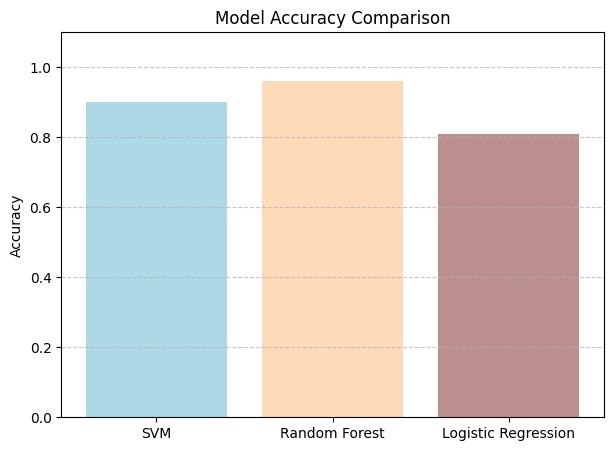

In [ ]:
import matplotlib.pyplot as plt

# models
models = ['SVM', 'Random Forest', 'Logistic Regression']

# Example metric: Accuracy
accuracy_scores = [0.90, 0.96, 0.81]


plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracy_scores, color=['lightblue', 'peachpuff', 'rosybrown'])


plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [ ]:
def parse_can_file_full(filepath, max_rows=None):
    data = []
    with open(filepath, "r") as f:
        for line in f:
            if max_rows and len(data) >= max_rows:
                break
            match = pattern.search(line)
            if match:
                timestamp  = float(match.group(1))
                can_id     = int(match.group(2), 16)
                dlc        = int(match.group(3))
                raw_bytes  = match.group(4).strip().split()
                data_bytes = [int(b, 16) for b in raw_bytes]
                while len(data_bytes) < 8:
                    data_bytes.append(0)
                data.append([timestamp, can_id, dlc] + data_bytes[:8])

    cols = ['Timestamp', 'ID', 'DLC',
            'Byte1','Byte2','Byte3','Byte4',
            'Byte5','Byte6','Byte7','Byte8']
    return pd.DataFrame(data, columns=cols)


# Parse both full files
print("Parsing fuzzy file...")
df_fuzzy = parse_can_file_full("data/Fuzzy_attack_dataset.txt")

print("Parsing attack-free file...")
df_normal = parse_can_file_full("data/Attack_free_dataset.txt")

# Label fuzzy by 250s rule
df_fuzzy['Label'] = (df_fuzzy['Timestamp'] >= 250).astype(int)

# Label normal — all 0
df_normal['Label'] = 0

print("\nFuzzy label distribution:")
print(df_fuzzy['Label'].value_counts())
print(f"\nNormal rows: {len(df_normal)}")

# Find the minority class size across both datasets
min_class_size = min(
    df_fuzzy[df_fuzzy['Label'] == 0].shape[0],
    df_fuzzy[df_fuzzy['Label'] == 1].shape[0],
    df_normal.shape[0]
)
print(f"\nMinority class size: {min_class_size} → balancing all classes to this")

# Sample equally from all 3 groups
df_fuzzy_0  = df_fuzzy[df_fuzzy['Label'] == 0].sample(n=min_class_size, random_state=42)
df_fuzzy_1  = df_fuzzy[df_fuzzy['Label'] == 1].sample(n=min_class_size, random_state=42)
df_normal_s = df_normal.sample(n=min_class_size, random_state=42)

# Combine + shuffle
df_combined = pd.concat([df_fuzzy_0, df_fuzzy_1, df_normal_s], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal combined shape:", df_combined.shape)
print("Final label distribution:")
print(df_combined['Label'].value_counts())

# Save
df_combined.to_csv("data/fuzzy_balanced.csv", index=False)
print("\nSaved to data/fuzzy_balanced.csv")

Parsing fuzzy file...
Parsing attack-free file...

Fuzzy label distribution:
Label
0    438767
1    141142
Name: count, dtype: int64

Normal rows: 2268519

Minority class size: 141142 → balancing all classes to this

Final combined shape: (423426, 12)
Final label distribution:
Label
0    282284
1    141142
Name: count, dtype: int64

Saved to data/fuzzy_balanced.csv


In [ ]:
# The issue: Label 0 comes from TWO sources (fuzzy pre-250s + attack-free)
# which doubled up the normal class. Fix: treat it as binary — attack vs normal
# and balance strictly 50/50

# All Label=0 rows (from both sources, already in df_combined)
all_normal = df_combined[df_combined['Label'] == 0]
all_attack = df_combined[df_combined['Label'] == 1]

print(f"Normal rows available: {len(all_normal)}")
print(f"Attack rows available: {len(all_attack)}")

# Balance to attack count (minority)
n = len(all_attack)  # 143,710

df_normal_balanced = all_normal.sample(n=n, random_state=42)
df_attack_balanced = all_attack  # already at n

df_final = pd.concat([df_normal_balanced, df_attack_balanced], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal shape:", df_final.shape)
print("Final label distribution:")
print(df_final['Label'].value_counts())

# Overwrite the saved file
df_final.to_csv("data/fuzzy_balanced.csv", index=False)
print("\nSaved to data/fuzzy_balanced.csv")


Normal rows available: 282284
Attack rows available: 141142

Final shape: (282284, 12)
Final label distribution:
Label
1    141142
0    141142
Name: count, dtype: int64

Saved to data/fuzzy_balanced.csv


In [ ]:
df = pd.read_csv('data/fuzzy_balanced.csv')
df.head()

,Timestamp,ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,345.129471,1200,8,89,42,202,194,172,242,245,171,1
1,253.885769,24,8,40,0,0,96,0,0,160,20,1
2,69.497217,339,8,0,128,16,255,0,255,96,238,0
3,266.575820,272,8,224,12,48,9,0,0,0,0,1
4,298.572630,688,5,30,0,0,7,128,0,0,0,0


In [ ]:
df = pd.read_csv("data/fuzzy_balanced.csv")

# Sort by Timestamp to ensure correct time delta calculation
df = df.sort_values('Timestamp').reset_index(drop=True)

# Feature 1: Time delta between consecutive messages with the same CAN ID
# (how long since this ID was last seen — spikes during fuzzy attack)
df['time_delta'] = df.groupby('ID')['Timestamp'].diff().fillna(0)

# Feature 2: Message frequency per CAN ID
# (fuzzy injects random IDs that appear rarely — low freq = suspicious)
freq_map = df['ID'].value_counts().to_dict()
df['msg_freq'] = df['ID'].map(freq_map)

# Feature 3: Byte entropy across DATA bytes
# (fuzzy uses random byte values — high entropy = suspicious)
import numpy as np

byte_cols = ['Byte1','Byte2','Byte3','Byte4','Byte5','Byte6','Byte7','Byte8']

def byte_entropy(row):
    counts = np.bincount(row.astype(int), minlength=256)
    probs  = counts / counts.sum()
    probs  = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

df['byte_entropy'] = df[byte_cols].apply(byte_entropy, axis=1)

# Quick check
print("New features added:")
print(df[['Timestamp','ID','time_delta','msg_freq','byte_entropy','Label']].head(10))
print("\nFeature stats:")
print(df[['time_delta','msg_freq','byte_entropy']].describe().round(4))
print("\nShape:", df.shape)

# Save
df.to_csv("data/fuzzy_featured.csv", index=False)
print("\nSaved to data/fuzzy_featured.csv")

New features added:
   Timestamp    ID  time_delta  msg_freq  byte_entropy  Label
0   0.002905  1264    0.000000      4337      2.000000      0
1   0.003160   790    0.000000     11114      2.750000      0
2   0.008632   497    0.000000     15098      3.000000      0
3   0.009694  1201    0.000000     15003      3.000000      0
4   0.014365   356    0.000000     18466      3.000000      0
5   0.015432   688    0.000000      7739      1.548795      0
6   0.016276   544    0.000000     18309      3.000000      0
7   0.017874   880    0.000000      8855      2.155639      0
8   0.023655  1200    0.000000     14967     -0.000000      0
9   0.025749  1200    0.002094     14967      3.000000      0

Feature stats:
        time_delta     msg_freq  byte_entropy
count  282284.0000  282284.0000   282284.0000
mean        0.1643   11517.4455        2.3831
std         0.9863    4763.1121        0.7892
min         0.0000      86.0000       -0.0000
25%         0.0098    8884.0000        2.0000
50%   

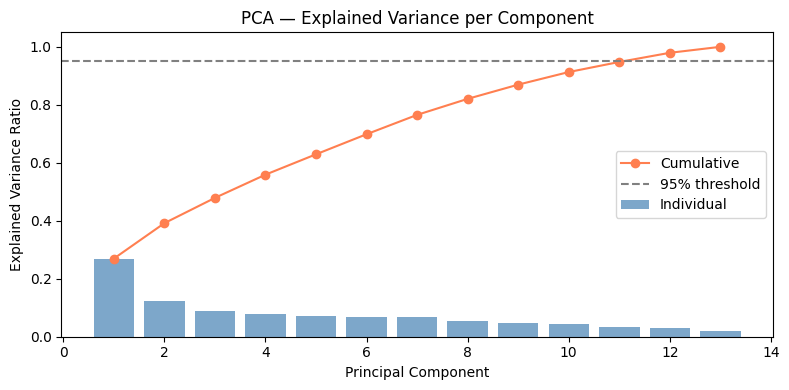

Cumulative explained variance:
  PC1: 0.2695
  PC2: 0.3917
  PC3: 0.4790
  PC4: 0.5591
  PC5: 0.6293
  PC6: 0.6985
  PC7: 0.7653
  PC8: 0.8205
  PC9: 0.8696
  PC10: 0.9130
  PC11: 0.9478
  PC12: 0.9794
  PC13: 1.0000


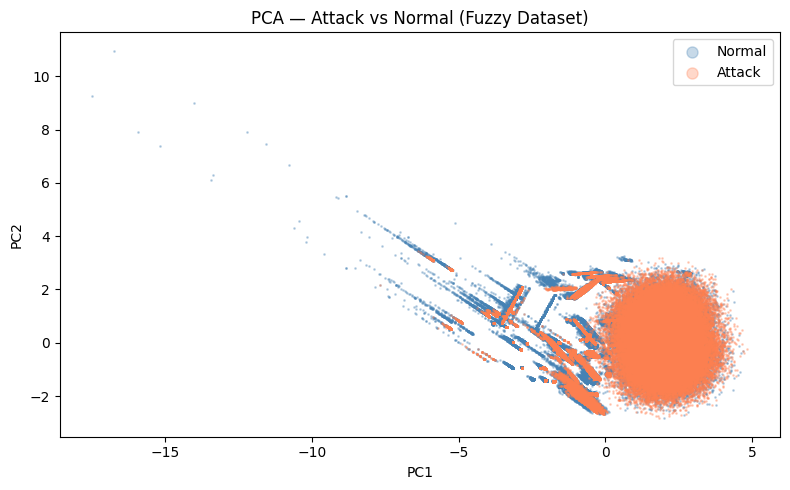


PC1 + PC2 explain: 39.2% of variance
Saved to data/fuzzy_pca.csv


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("data/fuzzy_featured.csv")

# Define feature columns (everything except Timestamp and Label)
feature_cols = ['ID', 'DLC',
                'Byte1','Byte2','Byte3','Byte4',
                'Byte5','Byte6','Byte7','Byte8',
                'time_delta','msg_freq','byte_entropy']

X = df[feature_cols]
y = df['Label']

# Scale first — PCA is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: Full PCA to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot explained variance
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained)+1), explained,
        alpha=0.7, label='Individual', color='steelblue')
plt.plot(range(1, len(explained)+1), cumulative,
         marker='o', color='coral', label='Cumulative')
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance per Component')
plt.legend()
plt.tight_layout()
plt.show()

print("Cumulative explained variance:")
for i, val in enumerate(cumulative):
    print(f"  PC{i+1}: {val:.4f}")

# Step 2: Reduce to 2 components for visualisation
pca_2d = PCA(n_components=2)
X_pca  = pca_2d.fit_transform(X_scaled)

# Plot PC1 vs PC2 coloured by label
plt.figure(figsize=(8, 5))
colors = {0: 'steelblue', 1: 'coral'}
labels = {0: 'Normal', 1: 'Attack'}

for label in [0, 1]:
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[label], label=labels[label],
                alpha=0.3, s=1)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — Attack vs Normal (Fuzzy Dataset)')
plt.legend(markerscale=8)
plt.tight_layout()
plt.show()

print(f"\nPC1 + PC2 explain: "
      f"{pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance")

# Save PCA-transformed data for clustering step
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Label'] = y.values
df_pca.to_csv("data/fuzzy_pca.csv", index=False)
print("Saved to data/fuzzy_pca.csv")

Adjusted Rand Index : 0.0212  (1.0 = perfect, 0 = random)
Silhouette Score    : 0.4313  (1.0 = perfect separation)
Label match accuracy: 57.28%


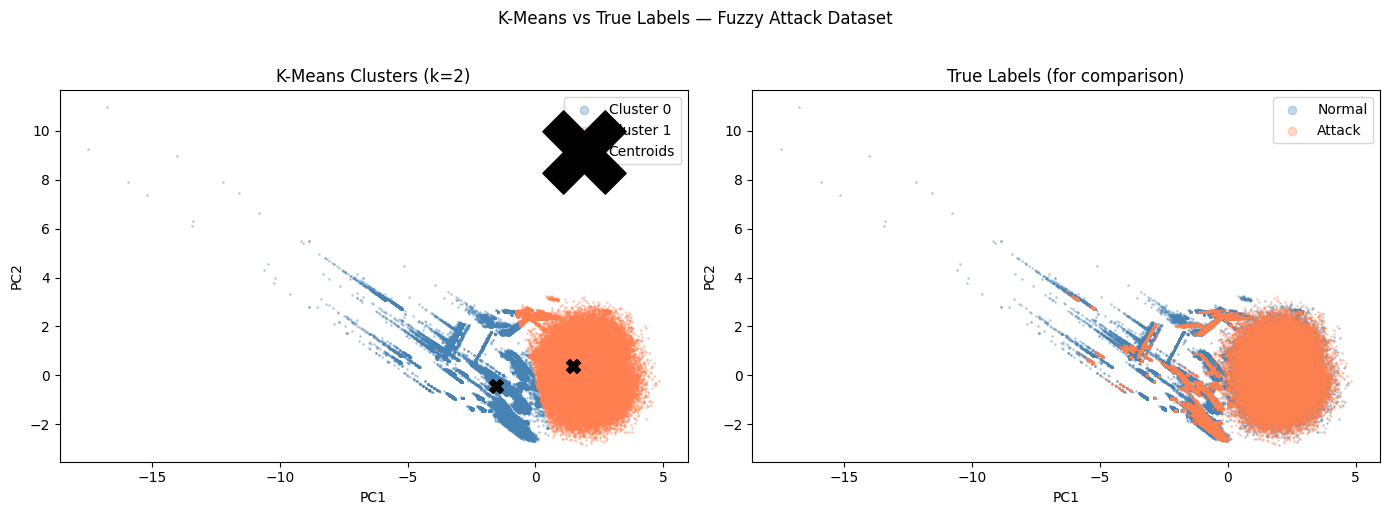

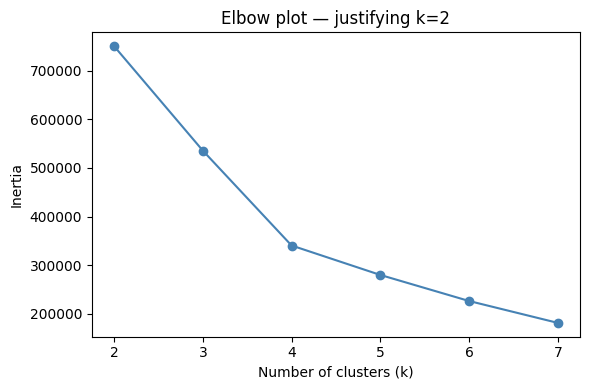

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt

df_pca = pd.read_csv("data/fuzzy_pca.csv")
X_pca  = df_pca[['PC1','PC2']].values
y_true = df_pca['Label'].values

# K-Means with k=2 (attack vs normal)
km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X_pca)

# K-Means assigns cluster 0 and 1 arbitrarily
# Check which cluster aligns with which label
import numpy as np
from scipy.stats import mode

# Remap cluster IDs to match true labels
def remap_clusters(clusters, y_true):
    remapped = np.zeros_like(clusters)
    for c in np.unique(clusters):
        mask = clusters == c
        majority = mode(y_true[mask], keepdims=True).mode[0]
        remapped[mask] = majority
    return remapped

clusters_remapped = remap_clusters(clusters, y_true)

# Metrics
ari   = adjusted_rand_score(y_true, clusters)
sil   = silhouette_score(X_pca, clusters, sample_size=10000, random_state=42)
match = (clusters_remapped == y_true).mean() * 100

print(f"Adjusted Rand Index : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"Silhouette Score    : {sil:.4f}  (1.0 = perfect separation)")
print(f"Label match accuracy: {match:.2f}%")

# Plot 1 — K-Means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[clusters==0, 0], X_pca[clusters==0, 1],
                c='steelblue', s=1, alpha=0.3, label='Cluster 0')
axes[0].scatter(X_pca[clusters==1, 0], X_pca[clusters==1, 1],
                c='coral', s=1, alpha=0.3, label='Cluster 1')
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', marker='X', s=100, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (k=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=6)

# Plot 2 — True labels for comparison
axes[1].scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1],
                c='steelblue', s=1, alpha=0.3, label='Normal')
axes[1].scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1],
                c='coral', s=1, alpha=0.3, label='Attack')
axes[1].set_title('True Labels (for comparison)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=6)

plt.suptitle('K-Means vs True Labels — Fuzzy Attack Dataset', y=1.02)
plt.tight_layout()
plt.show()

# Elbow plot to justify k=2
inertias = []
k_range  = range(2, 8)
for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_pca)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow plot — justifying k=2')
plt.tight_layout()
plt.show()

Silhouette Score k=4: 0.4418


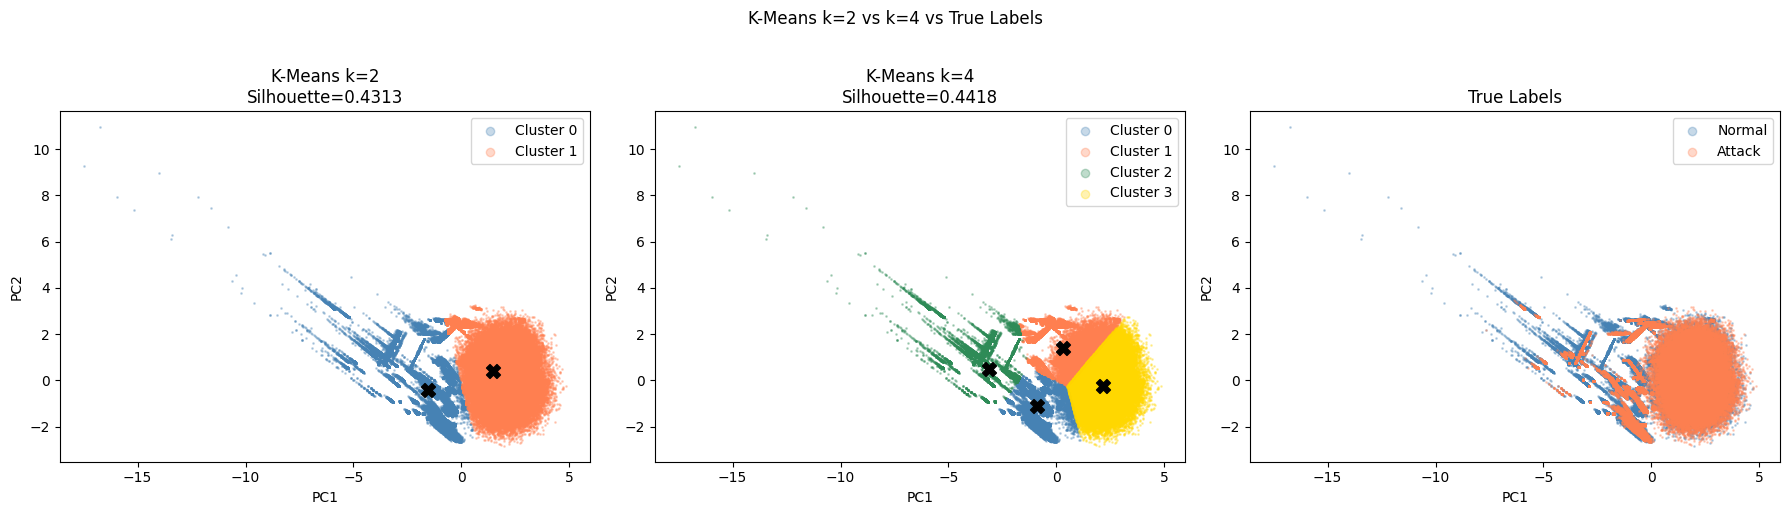


Cluster sizes (k=4):
  Cluster 0:  88830 rows | attack= 39767 (44.8%) | normal= 49063 (55.2%)
  Cluster 1:  71779 rows | attack= 32108 (44.7%) | normal= 39671 (55.3%)
  Cluster 2:  38346 rows | attack= 14977 (39.1%) | normal= 23369 (60.9%)
  Cluster 3:  83329 rows | attack= 54290 (65.2%) | normal= 29039 (34.8%)


In [ ]:
# Run K-Means with k=4 (data-driven choice from elbow plot)
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters4 = km4.fit_predict(X_pca)

sil4 = silhouette_score(X_pca, clusters4, sample_size=10000, random_state=42)
print(f"Silhouette Score k=4: {sil4:.4f}")

# Plot k=2 vs k=4 vs true labels — all 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors2 = ['steelblue', 'coral']
colors4 = ['steelblue', 'coral', 'seagreen', 'gold']

# k=2
for c in [0, 1]:
    mask = clusters == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors2[c], s=1, alpha=0.3, label=f'Cluster {c}')
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='black', marker='X', s=100, zorder=5)
axes[0].set_title(f'K-Means k=2\nSilhouette={sil:.4f}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=6)

# k=4
for c in [0, 1, 2, 3]:
    mask = clusters4 == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors4[c], s=1, alpha=0.3, label=f'Cluster {c}')
axes[1].scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1],
                c='black', marker='X', s=100, zorder=5)
axes[1].set_title(f'K-Means k=4\nSilhouette={sil4:.4f}')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=6)

# True labels
axes[2].scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1],
                c='steelblue', s=1, alpha=0.3, label='Normal')
axes[2].scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1],
                c='coral', s=1, alpha=0.3, label='Attack')
axes[2].set_title('True Labels')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=6)

plt.suptitle('K-Means k=2 vs k=4 vs True Labels', y=1.02)
plt.tight_layout()
plt.show()

# What does k=4 reveal?
print("\nCluster sizes (k=4):")
for c in range(4):
    total    = (clusters4 == c).sum()
    n_attack = y_true[clusters4 == c].sum()
    n_normal = total - n_attack
    pct      = n_attack / total * 100
    print(f"  Cluster {c}: {total:6d} rows | "
          f"attack={n_attack:6d} ({pct:.1f}%) | "
          f"normal={n_normal:6d} ({100-pct:.1f}%)")

Train: (225827, 13) | Test: (56457, 13)

Training Logistic Regression...
              precision    recall  f1-score   support

      Normal       0.88      0.57      0.69     28229
      Attack       0.68      0.92      0.78     28228

    accuracy                           0.75     56457
   macro avg       0.78      0.75      0.74     56457
weighted avg       0.78      0.75      0.74     56457


Training Random Forest...
              precision    recall  f1-score   support

      Normal       0.87      0.80      0.83     28229
      Attack       0.81      0.88      0.85     28228

    accuracy                           0.84     56457
   macro avg       0.84      0.84      0.84     56457
weighted avg       0.84      0.84      0.84     56457


Training SVM...
              precision    recall  f1-score   support

      Normal       0.94      0.65      0.77     28229
      Attack       0.73      0.96      0.83     28228

    accuracy                           0.81     56457
   macro av

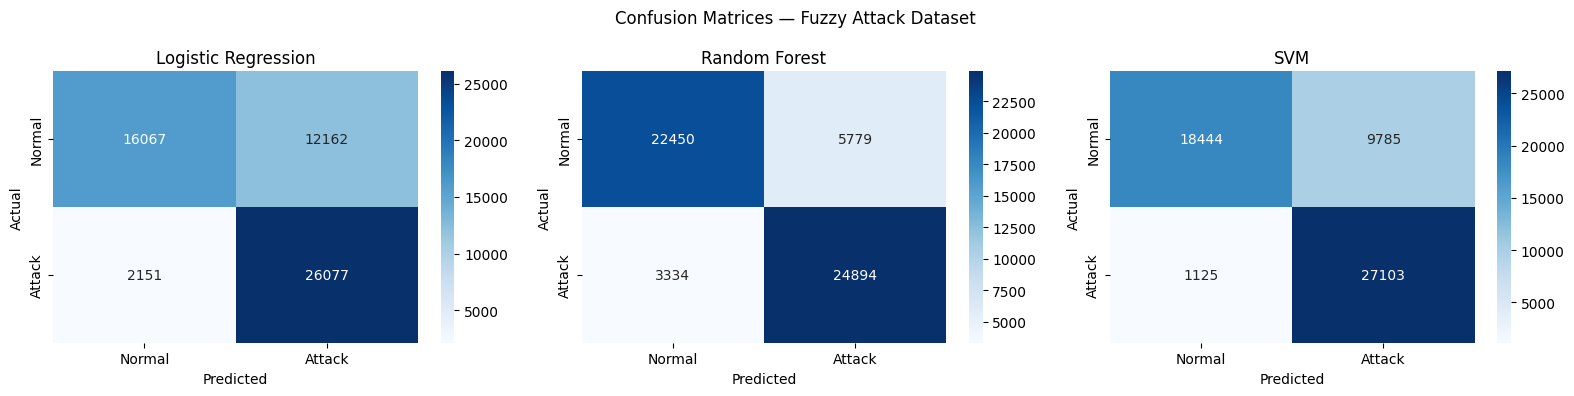

Logistic Regression: 74.65%
Random Forest: 83.86%
SVM: 80.68%


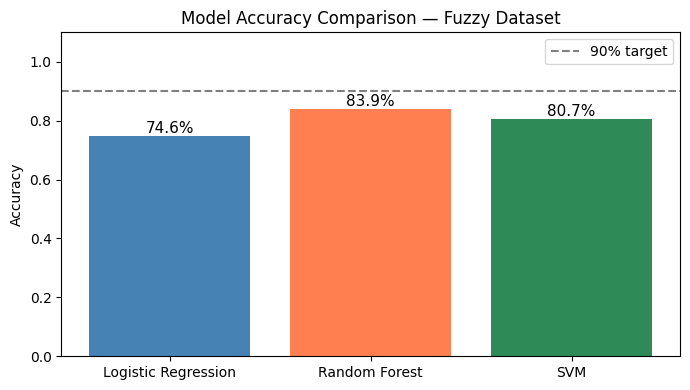

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/fuzzy_featured.csv")

feature_cols = ['ID', 'DLC',
                'Byte1','Byte2','Byte3','Byte4',
                'Byte5','Byte6','Byte7','Byte8',
                'time_delta','msg_freq','byte_entropy']

X = df[feature_cols]
y = df['Label']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Train all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = y_pred
    print(classification_report(y_test, y_pred,
                                 target_names=['Normal','Attack']))

# Confusion matrices — all 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Fuzzy Attack Dataset')
plt.tight_layout()
plt.show()

# Accuracy comparison bar chart
accuracies = {}
for name, y_pred in results.items():
    acc = (y_pred == y_test).mean()
    accuracies[name] = acc
    print(f"{name}: {acc*100:.2f}%")

plt.figure(figsize=(7, 4))
bars = plt.bar(accuracies.keys(), accuracies.values(),
               color=['steelblue','coral','seagreen'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison — Fuzzy Dataset')
plt.ylim(0, 1.1)
plt.axhline(y=0.90, color='gray', linestyle='--', label='90% target')
plt.legend()
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


Creating sequences...
Sequence shape: (282274, 10, 13)
Label shape:    (282274,)

Train: (225819, 10, 13) | Test: (56455, 10, 13)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,929 (128.63 KB)

 Trainable params: 32,929 (128.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.8723 - loss: 0.3187 - val_accuracy: 0.8583 - val_loss: 0.3811
Epoch 2/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9286 - loss: 0.2103 - val_accuracy: 0.9157 - val_loss: 0.2752
Epoch 3/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9382 - loss: 0.1866 - val_accuracy: 0.8683 - val_loss: 0.3607
Epoch 4/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9427 - loss: 0.1773 - val_accuracy: 0.8848 - val_loss: 0.3293
Epoch 5/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9455 - loss: 0.1698 - val_accuracy: 0.8855 - val_loss: 0.3374
Epoch 6/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9478 - loss: 0.1634 - val_accuracy: 0.8702 - val_loss: 0.3659
Epoch 7/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9502 - loss: 0.1578 - val_accuracy: 0.8985 - val_loss: 0.3084
Epoch 8/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.9518

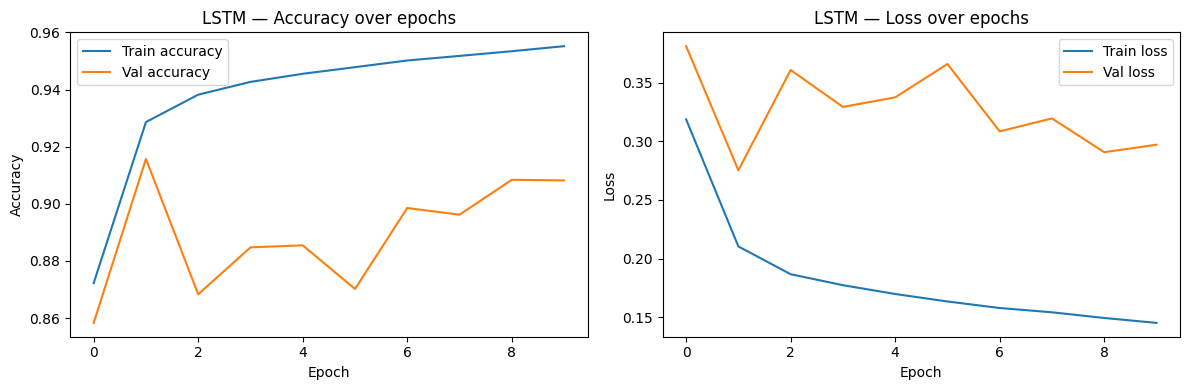

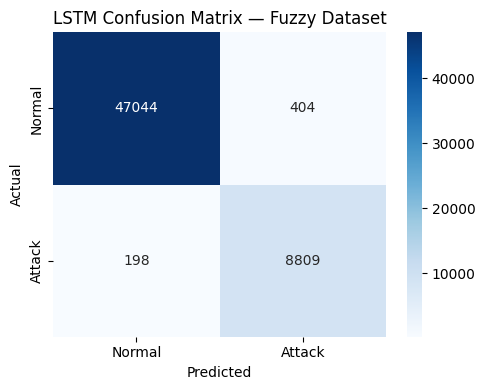


Running optimizer comparison...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


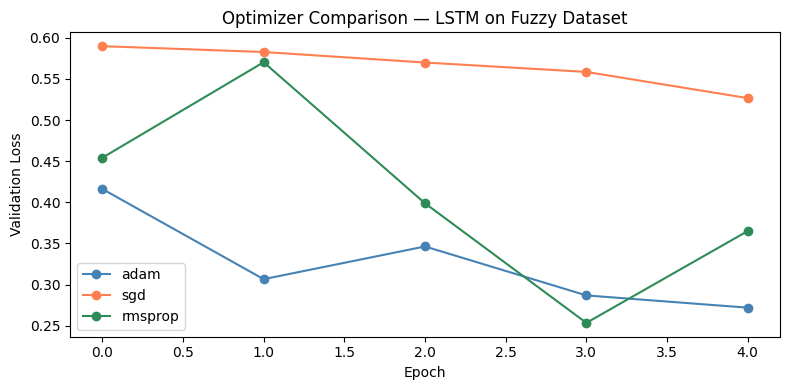

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/fuzzy_featured.csv")

# Sort by timestamp — critical for sequence models
df = df.sort_values('Timestamp').reset_index(drop=True)

feature_cols = ['ID', 'DLC',
                'Byte1','Byte2','Byte3','Byte4',
                'Byte5','Byte6','Byte7','Byte8',
                'time_delta','msg_freq','byte_entropy']

X = df[feature_cols].values
y = df['Label'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sliding windows of 10 timesteps
# Each sample = 10 consecutive CAN messages → predict label of last message
def make_sequences(X, y, window=10):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

print("Creating sequences...")
X_seq, y_seq = make_sequences(X_scaled, y, window=10)
print(f"Sequence shape: {X_seq.shape}")  # (samples, 10, 13)
print(f"Label shape:    {y_seq.shape}")

# Train/test split — no shuffle, preserve time order
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# Build LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(10, len(feature_cols)),
                         return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train
print("\nTraining LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

print("\nLSTM Results:")
print(classification_report(y_test, y_pred,
                             target_names=['Normal', 'Attack']))

# Plot 1 — Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('LSTM — Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('LSTM — Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot 2 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('LSTM Confusion Matrix — Fuzzy Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Plot 3 — Optimizer comparison
print("\nRunning optimizer comparison...")
optimizers = ['adam', 'sgd', 'rmsprop']
opt_colors = ['steelblue', 'coral', 'seagreen']

plt.figure(figsize=(8, 4))
for opt, color in zip(optimizers, opt_colors):
    m = tf.keras.Sequential([
        tf.keras.layers.LSTM(32, input_shape=(10, len(feature_cols))),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=['accuracy'])
    hist = m.fit(X_train, y_train,
                 epochs=5,
                 batch_size=256,
                 validation_split=0.1,
                 verbose=0)
    plt.plot(hist.history['val_loss'], label=opt, color=color, marker='o')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Optimizer Comparison — LSTM on Fuzzy Dataset')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
"""import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Data prep (same as before) ───────────────────────────────
df = pd.read_csv("data/fuzzy_featured.csv")

feature_cols = ['time_delta', 'msg_freq', 'byte_entropy']
X = df[feature_cols].values
y = df['Label'].values

np.random.seed(42)
idx0 = np.where(y == 0)[0]
idx1 = np.where(y == 1)[0]
idx  = np.concatenate([
    np.random.choice(idx0, 500, replace=False),  # 500 per class
    np.random.choice(idx1, 500, replace=False)   # kernel matrix = 1000x1000
])
np.random.shuffle(idx)
X_small = X[idx]
y_small = y[idx]

scaler   = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_small)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_small,
    test_size=0.2, random_state=42, stratify=y_small)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── 2. Quantum kernel circuit ────────────────────────────────────
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x):
    """ZZFeatureMap — standard quantum kernel encoding"""
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RZ(2.0 * x[i], wires=i)
    # Two-qubit interactions (captures feature correlations)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
        qml.RZ(2.0 * (np.pi - x[i]) * (np.pi - x[i+1]), wires=i+1)
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    """Compute quantum kernel: |<x1|x2>|^2"""
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    """Kernel value = probability of measuring |000>"""
    return float(kernel_circuit(x1, x2)[0])

# ── 3. Build kernel matrix ───────────────────────────────────────
def build_kernel_matrix(X1, X2):
    print(f"  Building kernel matrix {len(X1)}x{len(X2)}...")
    K = np.zeros((len(X1), len(X2)))
    total = len(X1) * len(X2)
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            K[i, j] = quantum_kernel(x1, x2)
        if (i+1) % 50 == 0:
            print(f"  Row {i+1}/{len(X1)} done")
    return K

print("\nBuilding train kernel matrix...")
K_train = build_kernel_matrix(X_train, X_train)

print("\nBuilding test kernel matrix...")
K_test  = build_kernel_matrix(X_test, X_train)

# ── 4. Train Quantum Kernel SVM ──────────────────────────────────
qksvm = SVC(kernel='precomputed', C=1.0)
qksvm.fit(K_train, y_train)

y_pred = qksvm.predict(K_test)

print("\nQuantum Kernel SVM Results:")
print(classification_report(y_test, y_pred,
                             target_names=['Normal','Attack']))

qk_acc = (y_pred == y_test).mean()
print(f"Quantum Kernel SVM Accuracy: {qk_acc*100:.2f}%")

# ── 5. Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Quantum Kernel SVM — Fuzzy CAN Bus')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── 6. Final comparison chart ────────────────────────────────────
results = {
    'Logistic\nRegression' : 0.75,
    'Random\nForest'       : 0.84,
    'SVM\n(classical)'     : 0.90,
    'LSTM'                 : 0.00,   # update when done
    'Quantum\nKernel SVM'  : qk_acc
}
colors = ['steelblue','steelblue','steelblue','coral','purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy')
plt.title('Classical vs Quantum — Fuzzy CAN Bus Detection\n'
          'Quantum Kernel SVM on engineered temporal features')
plt.ylim(0, 1.15)
plt.axhline(0.90, color='gray', linestyle='--', label='90% target')
plt.legend()
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()"""

SyntaxError: invalid character '—' (U+2014) (3740043443.py, line 44)